# Flow of a Stokes fluid with vertical forcing

$$
\mathbb{S}
\begin{cases}
\Omega = [0, L_x] \times [0, L_y] \\
\psi_{\text{D}}\vert_{\partial\Omega} = 0 & \text{equivalent to no-penetration } (\textbf{n}\cdot\textbf{u})\vert_{\partial\Omega}=0\\
\psi_{\text{L}}\vert_{\partial\Omega} = 0 & \text{equivalent to no-stress } \left(\textbf{n}\cdot\left(\nabla\textbf{u} + \nabla\textbf{u}^{\mathsf{T}}\right)\right)\vert_{\partial\Omega}=0 \\
f_x = 0 \\
f_y(x,y) = 5y\sin(6\pi x/L_x) \\
\end{cases}
$$


In [ ]:
import numpy as np
from lucifex.mesh import rectangle_mesh, mesh_boundary
from lucifex.fem import Function, Constant, cross_section
from lucifex.solver import bvp, interpolation, BoundaryConditions
from lucifex.viz import plot_colormap, plot_line, plot_contours, save_figure
from lucifex.utils.fenicsx_utils import get_component_functions
from lucifex.pde.streamfunction_vorticity import velocity_from_streamfunction
from lucifex.pde.stokes import stokes_streamfunction

Lx = 2.0
Ly = 1.0
mesh = rectangle_mesh(Lx, Ly, 128, 64, 'quadrilateral')
boundary = mesh_boundary(
    mesh, 
    {
        "left": lambda x: x[0],
        "right": lambda x: x[0] - Lx,
        "lower": lambda x: x[1],
        "upper": lambda x: x[1] - Ly,
    },
)

alpha = Constant(mesh, 8.0, name='alpha')
fx = None
fy = Function(
    (mesh, 'P', 1), 
    lambda x: 5 * x[1] * np.sin(6 * np.pi * x[0] / Lx),
    name='fy',
)

bcs = BoundaryConditions(
    ('essential', boundary.union, 0.0),
)

psi = Function((mesh, 'P', 2), name="psi")
psi_solver = bvp(stokes_streamfunction, bcs)(psi, alpha, fx, fy)
psi_solver.solve()

u = Function((mesh, 'P', 1, 2), name='u')
u_solver = interpolation(u, velocity_from_streamfunction)(psi)
u_solver.solve()

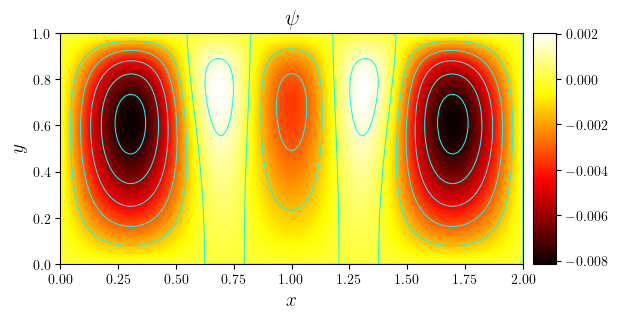

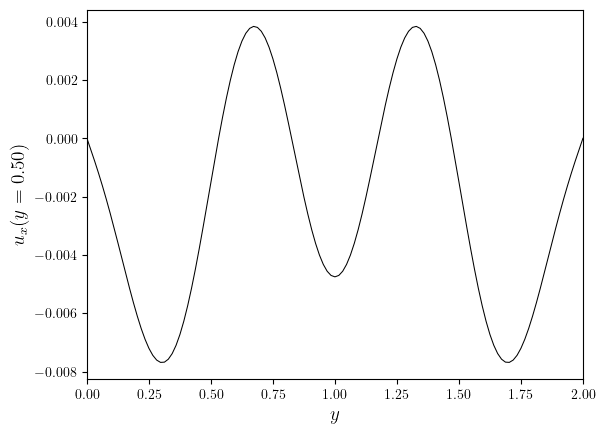

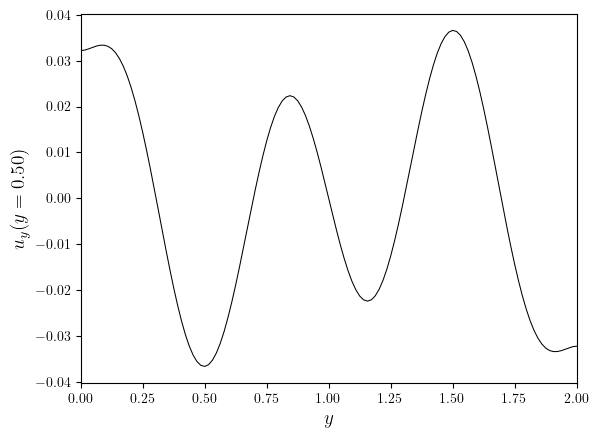

In [2]:
fig, ax = plot_colormap(psi, title='$\psi$', x_label='$x$', y_label='$y$')
plot_contours(fig, ax, psi, use_cache=True, colors='cyan')
save_figure('psi(x,y)', thumbnail=True)(fig)

ux, uy = get_component_functions(('P', 1), u, names=('ux', 'uy'))

x_axis, ux_x, y_value = grid_cross_section(ux, 'y', 0.5)
fig, ax = plot_line((x_axis, ux_x), x_label='$y$', y_label=f'${u.name}_x(y={y_value:.2f})$')
save_figure(f'ux(x,y={y_value:.2f}')(fig)

x_axis, uy_x, y_value = grid_cross_section(uy, 'y', 0.5)
fig, ax = plot_line((x_axis, uy_x), x_label='$y$', y_label=f'${u.name}_y(y={y_value:.2f})$')
save_figure(f'uy(x,y={y_value:.2f}')(fig)
